### Setup: Import Libraries and Load Dataset

First, let's import the necessary libraries (`pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`) and load a suitable dataset. I've chosen the 'Adult Census Income' dataset from OpenML, as it has over 1000 rows, 14 columns, and a mix of numeric and categorical features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Load the Adult Census Income dataset from OpenML
# This dataset has ~48k rows and 14 features (mixed numeric and categorical)
adult_data = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')
df = adult_data.frame

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset loaded with 48842 rows and 15 columns.

First 5 rows of the dataset:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


### 1. Central Tendency of Data (Visual; Numeric)

We can visualize the central tendency (mean, median, mode) and distribution of a numeric variable using a **histogram** and a **box plot**.

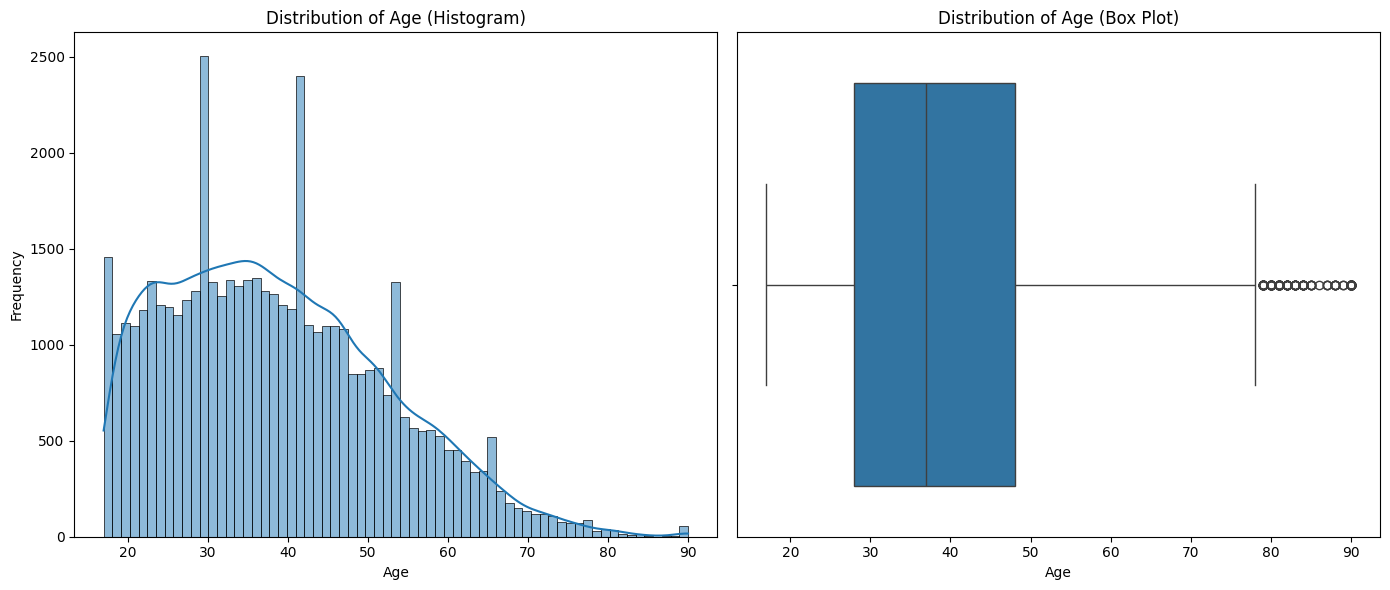

In [ ]:
plt.figure(figsize=(14, 6))

# Histogram for 'age'
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age (Histogram)')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Box plot for 'age'
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(x=df['age'])
plt.title('Distribution of Age (Box Plot)')
plt.xlabel('Age')

plt.tight_layout()
plt.show()

### 2. Outlier Identification (Visual; Numeric)

Box plots are excellent for identifying outliers. Outliers are typically represented as points extending beyond the 'whiskers' of the box plot. Let's use the 'hours-per-week' column. To ensure we have clear outliers, we'll also artificially add a few extreme values if they aren't prominent.

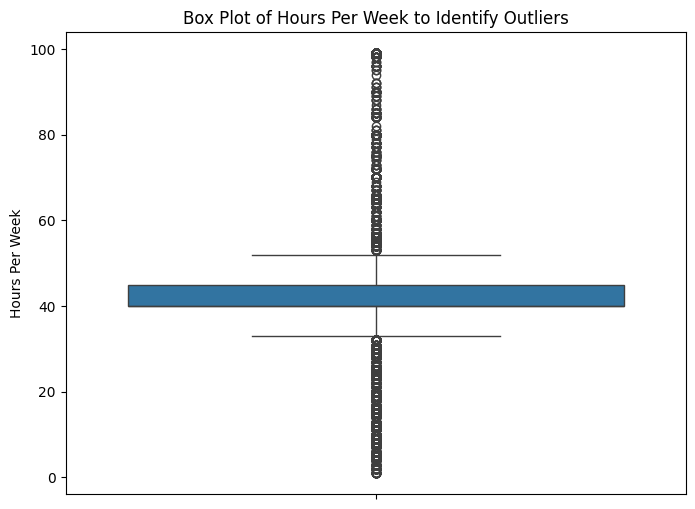

Original descriptive statistics for 'hours-per-week':
count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


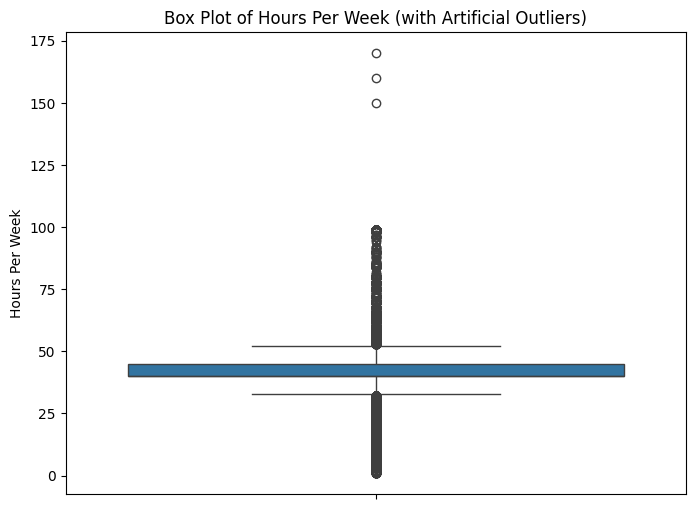

Descriptive statistics for 'hours-per-week' with artificial outliers:
count    48845.000000
mean        40.429727
std         12.426614
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max        170.000000
dtype: float64


In [ ]:
# Using 'hours-per-week' to identify outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['hours-per-week'])
plt.title('Box Plot of Hours Per Week to Identify Outliers')
plt.ylabel('Hours Per Week')
plt.show()

print("Original descriptive statistics for 'hours-per-week':")
print(df['hours-per-week'].describe())

# Artificially add outliers to demonstrate if they are not very prominent
# Create a copy to avoid modifying the original DataFrame for later steps
df_with_outliers = df['hours-per-week'].copy()

# Add some extremely high values
df_with_outliers = pd.concat([df_with_outliers, pd.Series([150, 160, 170])])

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_with_outliers)
plt.title('Box Plot of Hours Per Week (with Artificial Outliers)')
plt.ylabel('Hours Per Week')
plt.show()

print("Descriptive statistics for 'hours-per-week' with artificial outliers:")
print(df_with_outliers.describe())

### 3. Visualizing Relationship Between 2 Numeric Variables

A **scatter plot** is ideal for showing the relationship between two continuous numeric variables. Let's visualize the relationship between 'age' and 'hours-per-week'.

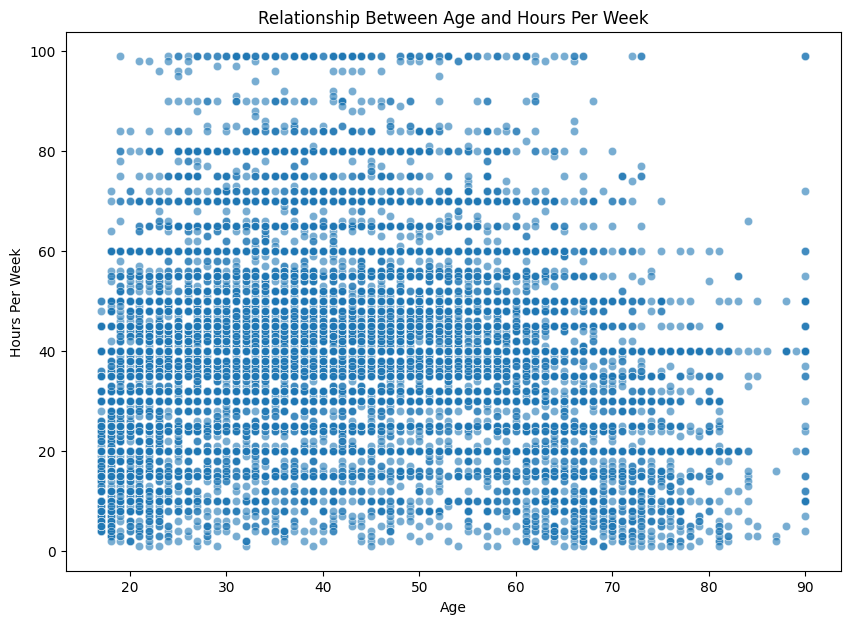

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='hours-per-week', data=df, alpha=0.6)
plt.title('Relationship Between Age and Hours Per Week')
plt.xlabel('Age')
plt.ylabel('Hours Per Week')
plt.show()

### 4. Visualizing Relationship Between Numeric and Nominal Variable

To see the relationship between a numeric variable and a nominal (categorical) variable, **box plots** or **violin plots** grouped by the categorical variable are effective. Let's look at the 'age' across different 'education' levels.

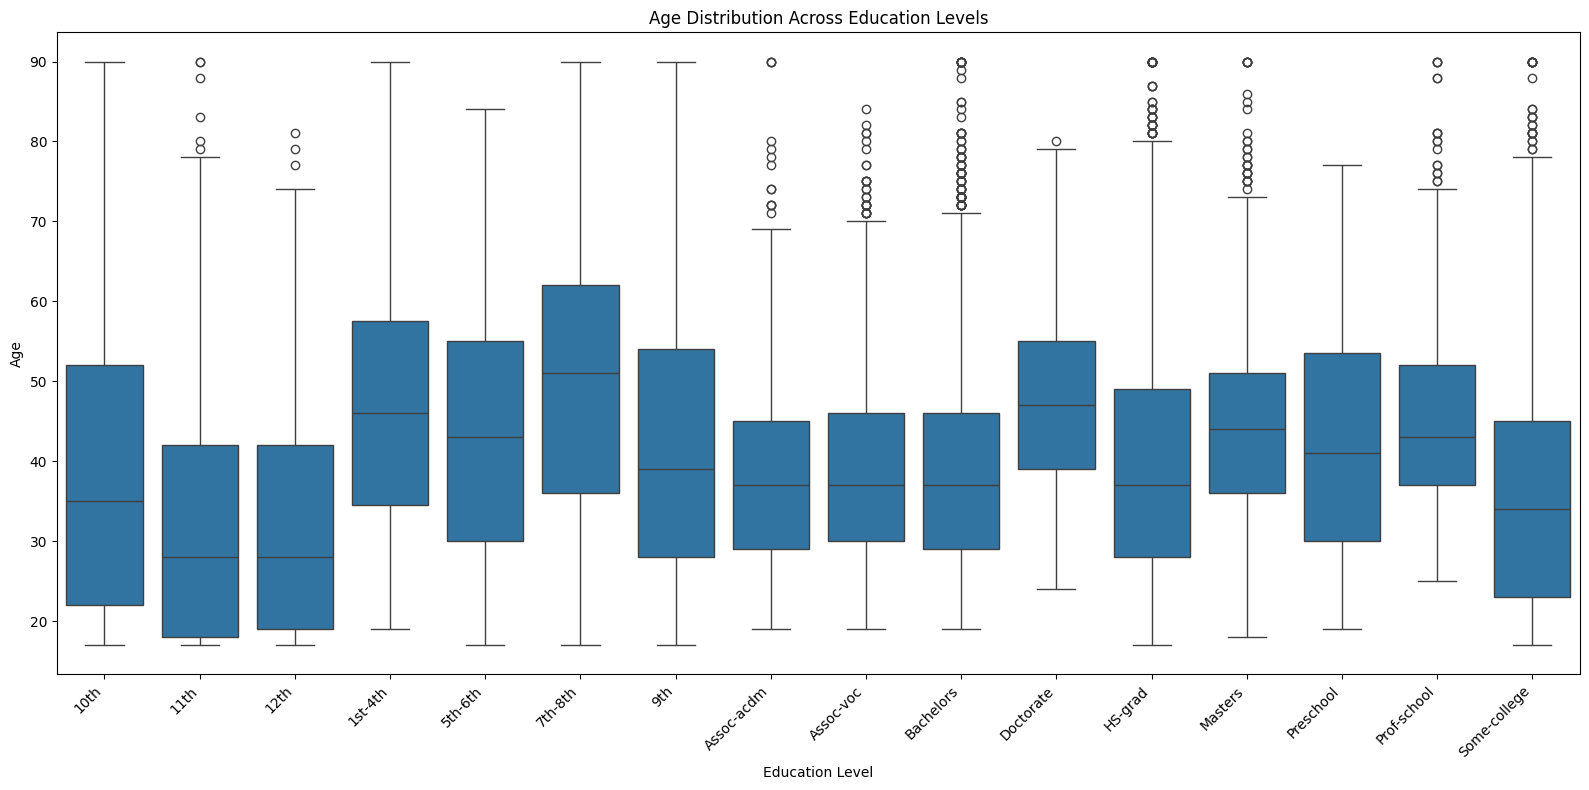

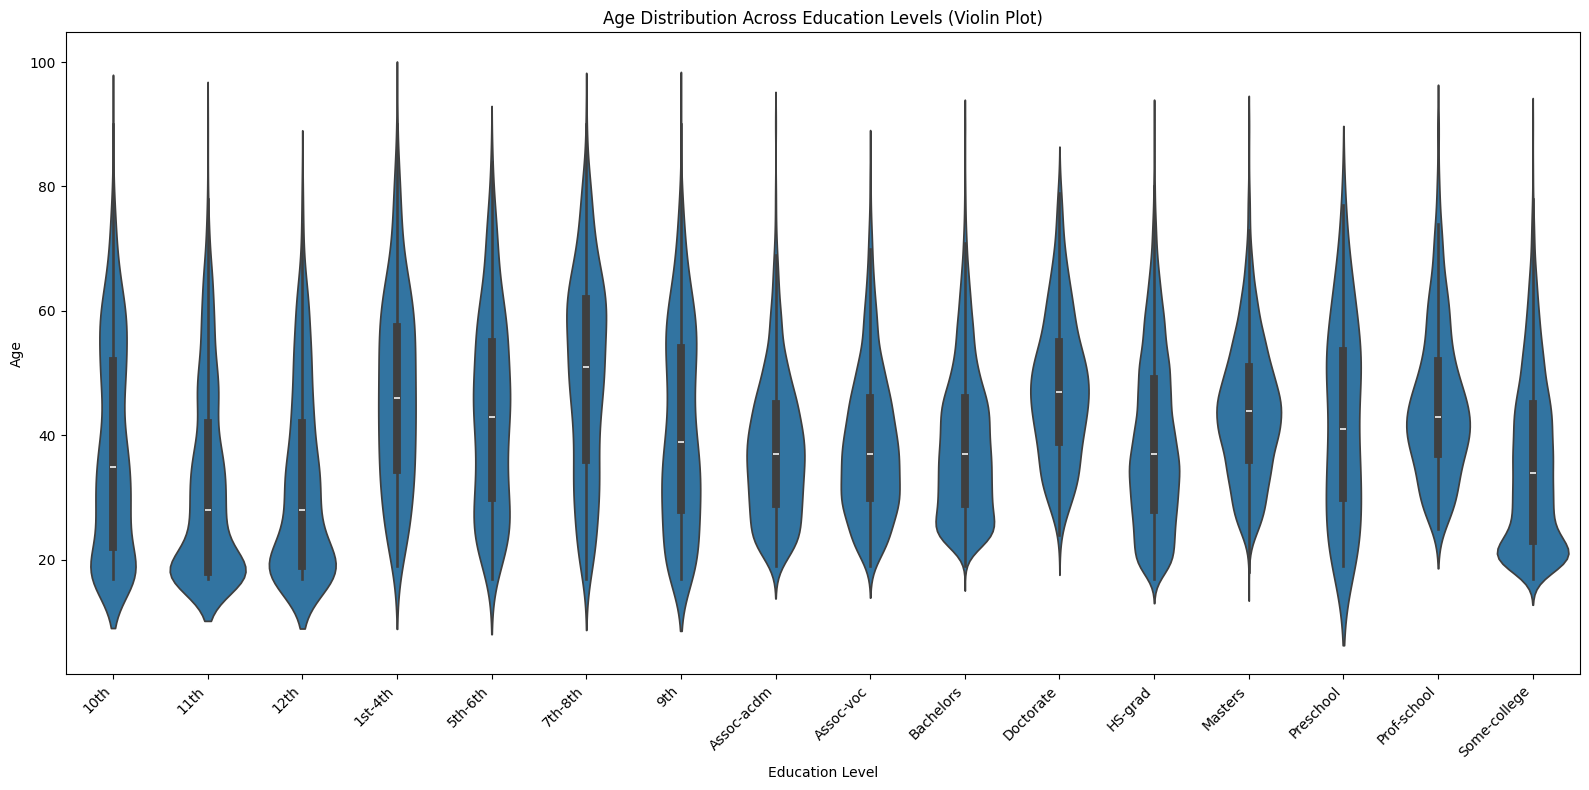

In [ ]:
plt.figure(figsize=(16, 8))
sns.boxplot(x='education', y='age', data=df)
plt.title('Age Distribution Across Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))
sns.violinplot(x='education', y='age', data=df)
plt.title('Age Distribution Across Education Levels (Violin Plot)')
plt.xlabel('Education Level')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5. Visualizing Relationship Between Two Nominal Variables

For two nominal variables, a **count plot** (for showing frequencies) or a **heatmap of a cross-tabulation** (for showing proportions/counts) can be used. Let's examine the relationship between 'workclass' and 'income' (whether income is >50K or <=50K).

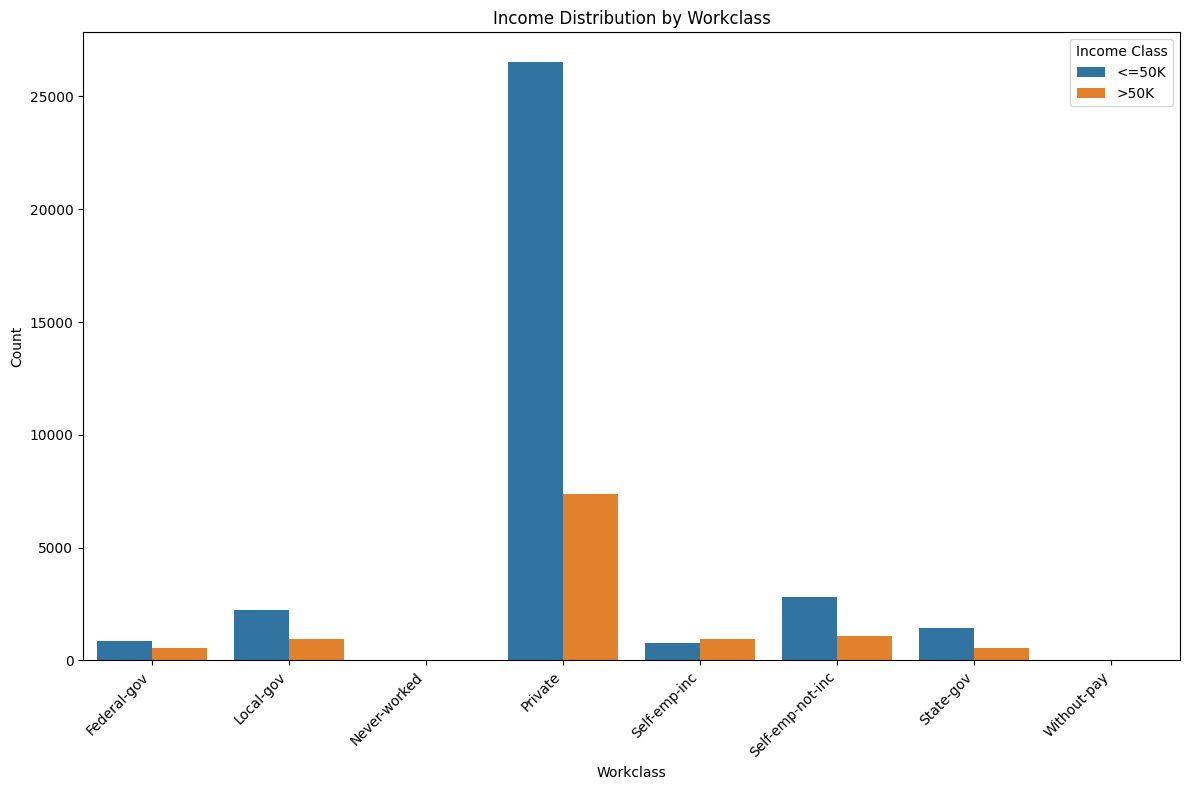

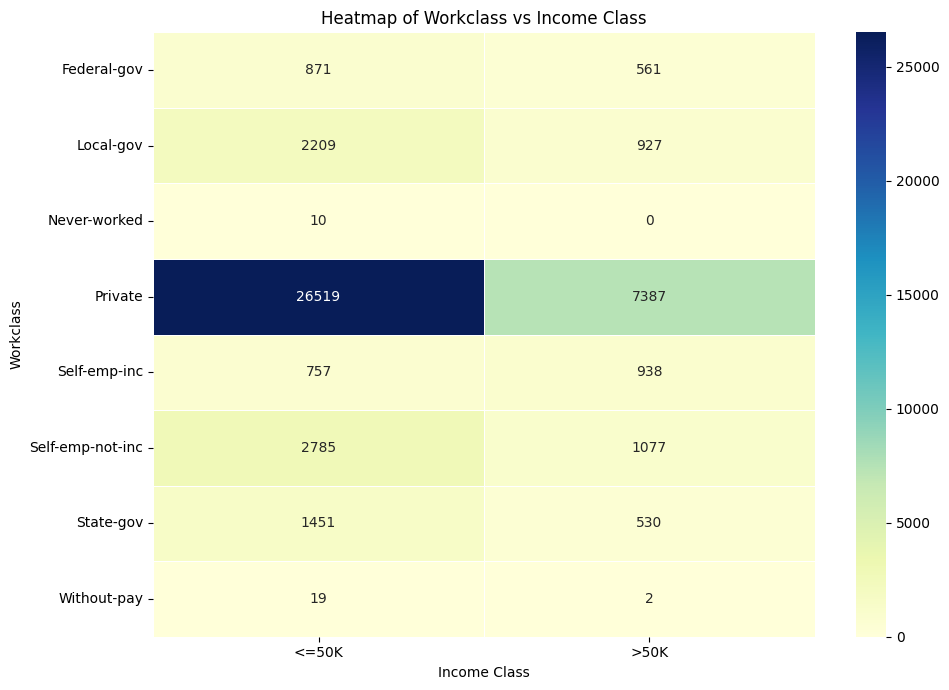

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(x='workclass', hue='class', data=df)
plt.title('Income Distribution by Workclass')
plt.xlabel('Workclass')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Income Class')
plt.tight_layout()
plt.show()


# Create a cross-tabulation (contingency table)
contingency_table = pd.crosstab(df['workclass'], df['class'])

plt.figure(figsize=(10, 7))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap of Workclass vs Income Class')
plt.xlabel('Income Class')
plt.ylabel('Workclass')
plt.tight_layout()
plt.show()